# 01 - Conocimiento del usuario

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
import unicodedata
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline

In [3]:
#Configuración
SEMILLA = 20260724
UMBRAL_ALCANCE = 0.50
PESO_MODELO = 0.55
PESO_CATALOGO = 0.45
VERSION_MODELO = 'fincoach_usuario_mvp_v2'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'plataforma', 'version': platform.platform()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
])

display(versiones)

,componente,version
0,python,3.14.3
1,plataforma,macOS-26.5.2-arm64-arm-64bit-Mach-O
2,pandas,3.0.3
3,numpy,2.5.1
4,scikit-learn,1.9.0


## 3. Carga del dataset

In [4]:
#Dataset
ruta_dataset = Path('../Datasets/perfil_integral_usuario.csv')
perfiles = pd.read_csv(ruta_dataset, low_memory=False)
display(perfiles.head(5))

,perfil_id,version_perfil,vigencia_desde,pais,moneda,descripcion_visible,nivel_informacion_visible,estado_alcance_mvp,actividad_1_familia,actividad_1_codigo_cuoc,...,tiene_ingreso_adicional,ingreso_adicional,modalidad_ingreso_adicional,objetivo_proximo,hobbies,responsabilidad_financiera,tipos_deuda,nivel_endeudamiento_pct,estado_calculo_endeudamiento,habito_ahorro
0,PERF_0001,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Ingeniero de so...,parcial,dentro_del_mvp,ingenieria_y_desarrollo_de_software,25120,...,si,actividad independiente adicional,variable,crear fondo emergencia,pintura | turismo_y_viajes,gastos de un hijo,credito,4.93,calculado,media
1,PERF_0002,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Nutricionista d...,parcial,dentro_del_mvp,nutricion_y_dietetica,22650,...,no,NaN,NaN,ampliar actividad economica,cocina_y_reposteria | fotografia_y_video,aporte hogar compartido,credito,0.00,calculado,alta
2,PERF_0003,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Disc jockey. Es...,parcial,dentro_del_mvp,musica_y_entretenimiento_dj,26521,...,si,Editor de video / Editora de video,variable,no declarado,manualidades_y_artesanias | impresion_3d,no declarada,credito,3.16,calculado,baja
3,PERF_0004,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Ciclista. Estad...,parcial,dentro_del_mvp,deporte_competitivo_ciclismo,34210,...,no,NaN,NaN,no declarado,musica | fotografia_y_video,gastos de un hijo,credito,10.90,calculado,media
4,PERF_0005,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Repartidor de d...,parcial,dentro_del_mvp,domicilios_mensajeria_y_reparto,96211,...,no,NaN,NaN,no declarado,fotografia_y_video | ciclismo,apoyo parcial a dos familiares,credito,35.50,calculado,alta


In [5]:
#Resumen del dataset
resumen_dataset = pd.DataFrame([{
    'filas': len(perfiles),
    'columnas': perfiles.shape[1],
    'perfiles_unicos': perfiles['perfil_id'].nunique(),
    'actividades_principales': perfiles['actividad_1_familia'].nunique(),
    'hobbies_disponibles': len(set(perfiles['hobby_1'].dropna()) | set(perfiles['hobby_2'].dropna())),
    'perfiles_ingreso': perfiles['estado_ingreso_actual'].nunique(),
}])

display(resumen_dataset)

,filas,columnas,perfiles_unicos,actividades_principales,hobbies_disponibles,perfiles_ingreso
0,200,58,200,10,10,6


## 4. Contrato y particiones

In [6]:
#Validar contrato
columnas_requeridas = [
    'perfil_id',
    'estado_alcance_mvp',
    'actividad_principal_declarada',
    'actividad_1_familia',
    'actividad_1_codigo_cuoc',
    'actividad_1_ocupacion_cuoc',
    'estado_ingreso_actual',
    'ingreso_mensual_neto',
    'ingreso_principal',
    'modalidad_ingreso_principal',
    'tiene_ingreso_adicional',
    'ingreso_adicional',
    'modalidad_ingreso_adicional',
    'objetivo_proximo',
    'hobbies',
    'responsabilidad_financiera',
    'tipos_deuda',
    'nivel_endeudamiento_pct',
    'estado_calculo_endeudamiento',
    'habito_ahorro',
    'hobby_1',
    'hobby_2',
    'particion',
    'version_esquema',
]

columnas_ausentes = [columna for columna in columnas_requeridas if columna not in perfiles.columns]
particiones_esperadas = {'train', 'validation', 'test'}
particiones_encontradas = set(perfiles['particion'].dropna().unique())

assert not columnas_ausentes, f'Faltan columnas: {columnas_ausentes}'
assert perfiles['perfil_id'].is_unique, 'perfil_id contiene duplicados'
assert particiones_encontradas == particiones_esperadas, 'Las particiones no coinciden con train, validation y test'
assert perfiles['actividad_principal_declarada'].fillna('').str.strip().ne('').all(), 'Existen actividades principales vacías'
print('Contrato y particiones: OK')

Contrato y particiones: OK


In [7]:
#Particiones
datos_modelo = perfiles.loc[perfiles['estado_alcance_mvp'].eq('dentro_del_mvp')].copy()
mascara_train = datos_modelo['particion'].eq('train')
mascara_validation = datos_modelo['particion'].eq('validation')
mascara_test = datos_modelo['particion'].eq('test')

resumen_particiones = datos_modelo.groupby('particion').agg(
    filas=('perfil_id', 'size'),
    perfiles=('perfil_id', 'nunique'),
    actividades=('actividad_1_familia', 'nunique'),
).reindex(['train', 'validation', 'test'])

assert mascara_train.any() and mascara_validation.any() and mascara_test.any(), 'Alguna partición está vacía'
display(resumen_particiones)

,filas,perfiles,actividades
particion,,,
train,140,140,10
validation,30,30,10
test,30,30,10


## 5. Modelo cerrado del MVP

In [8]:
#Catálogos del MVP
catalogo_actividades = datos_modelo[[
    'actividad_1_familia',
    'actividad_1_codigo_cuoc',
    'actividad_1_ocupacion_cuoc',
    'actividad_principal_declarada',
]].drop_duplicates().sort_values('actividad_1_familia').reset_index(drop=True)

catalogo_hobbies = sorted(set(
    datos_modelo['hobby_1'].dropna().tolist()
    + datos_modelo['hobby_2'].dropna().tolist()
))

modalidades_ingreso = ['fijo', 'variable', 'mixto', 'estacional', 'sin_ingresos', 'apoyo']
habitos_ahorro = ['nunca', 'baja', 'media', 'alta']

display(catalogo_actividades)
display(pd.DataFrame({'hobby_disponible': catalogo_hobbies}))
display(pd.DataFrame({'modalidad_ingreso': modalidades_ingreso}))

,actividad_1_familia,actividad_1_codigo_cuoc,actividad_1_ocupacion_cuoc,actividad_principal_declarada
0,agricultura,61131,"Agricultores de huertas, invernaderos, viveros...",Horticultor / Horticultora
1,deporte_competitivo_ciclismo,34210,Atletas y deportistas,Ciclista
2,diseno_audiovisual_y_edicion_de_video,26541,"Productores, directores y editores de cine, te...",Editor de video / Editora de video
3,docencia_y_formacion,23300,Profesores de educación secundaria / Profesora...,Docente de educación básica secundaria
4,domicilios_mensajeria_y_reparto,96211,"Mandaderos, maleteros y repartidores / Mandade...",Repartidor de domicilios / Repartidora de domi...
5,ingenieria_y_desarrollo_de_software,25120,Desarrolladores de software / Desarrolladoras ...,Ingeniero de software / Ingeniera de software
6,musica_y_entretenimiento_dj,26521,Intérpretes musicales,Disc jockey
7,nutricion_y_dietetica,22650,Nutricionistas dietistas,Nutricionista dietista
8,peluqueria_y_barberia,51410,Peluqueros / Peluqueras,Barbero / Barbera
9,ventas_al_por_menor,52230,"Vendedores y auxiliares de venta en tiendas, a...",Vendedor de tienda / Vendedora de tienda


,hobby_disponible
0,ciclismo
1,cocina_y_reposteria
2,fotografia_y_video
3,impresion_3d
4,jardineria_y_agricultura_urbana
5,manualidades_y_artesanias
6,musica
7,pintura
8,turismo_y_viajes
9,videojuegos_y_streaming


,modalidad_ingreso
0,fijo
1,variable
2,mixto
3,estacional
4,sin_ingresos
5,apoyo


In [9]:
#Balance
balance_actividad = pd.crosstab(
    datos_modelo['actividad_1_familia'],
    datos_modelo['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_completa = balance_actividad.gt(0).all(axis=1)
balance_actividad['cobertura_completa'] = cobertura_completa

display(balance_actividad)
assert cobertura_completa.all(), 'Alguna actividad no aparece en las tres particiones'

particion,train,validation,test,cobertura_completa
actividad_1_familia,,,,
agricultura,14,3,3,True
deporte_competitivo_ciclismo,14,3,3,True
diseno_audiovisual_y_edicion_de_video,14,3,3,True
docencia_y_formacion,14,3,3,True
domicilios_mensajeria_y_reparto,14,3,3,True
ingenieria_y_desarrollo_de_software,14,3,3,True
musica_y_entretenimiento_dj,14,3,3,True
nutricion_y_dietetica,14,3,3,True
peluqueria_y_barberia,14,3,3,True


## 6. Actividad principal

In [10]:
#Definir modelos
def crear_pipeline(clasificador):
    return Pipeline([
        ('texto', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(2, 5),
            lowercase=True,
            strip_accents='unicode',
            min_df=1,
            sublinear_tf=True,
        )),
        ('clasificador', clasificador),
    ])


variantes_actividad = {
    'ingenieria_y_desarrollo_de_software': ['ingeniero de software', 'ingeniera de software', 'desarrollador de software', 'desarrolladora de software', 'programador de software', 'desarrollo de software'],
    'nutricion_y_dietetica': ['nutricionista dietista', 'nutricionista', 'dietista', 'nutricion y dietetica'],
    'musica_y_entretenimiento_dj': ['disc jockey', 'dj', 'interprete musical', 'musica y entretenimiento dj'],
    'deporte_competitivo_ciclismo': ['ciclista', 'atleta de ciclismo', 'deportista de ciclismo', 'ciclismo competitivo'],
    'domicilios_mensajeria_y_reparto': ['repartidor de domicilios', 'repartidora de domicilios', 'mensajero', 'mensajera', 'repartidor'],
    'ventas_al_por_menor': ['vendedor de tienda', 'vendedora de tienda', 'ventas al por menor', 'venta en tienda', 'ventas en almacenes', 'venta de alimentos al por menor'],
    'diseno_audiovisual_y_edicion_de_video': ['editor de video', 'editora de video', 'edicion de video', 'editor audiovisual'],
    'docencia_y_formacion': ['docente de educacion basica secundaria', 'profesor de secundaria', 'profesora de secundaria', 'docencia secundaria'],
    'agricultura': ['horticultor', 'horticultora', 'agricultor de huerta', 'agricultora de huerta', 'agricultura de huertas'],
    'peluqueria_y_barberia': ['barbero', 'barbera', 'peluquero', 'peluquera', 'peluqueria y barberia'],
}

muestras_catalogo = pd.DataFrame([
    {'texto': texto, 'actividad': actividad}
    for actividad, variantes in variantes_actividad.items()
    for texto in variantes
])

assert set(variantes_actividad) == set(catalogo_actividades['actividad_1_familia']), 'Las variantes no cubren las diez actividades'


candidatos_actividad = {
    'regresion_logistica': crear_pipeline(LogisticRegression(
        C=10.0,
        max_iter=4000,
        class_weight='balanced',
        random_state=SEMILLA,
    )),
    'naive_bayes_complementario': crear_pipeline(ComplementNB(alpha=0.25)),
}

In [11]:
#Comparar modelos
X_train_base = datos_modelo.loc[mascara_train, 'actividad_principal_declarada']
y_train = datos_modelo.loc[mascara_train, 'actividad_1_familia']
X_train = pd.concat([X_train_base, muestras_catalogo['texto']], ignore_index=True)
y_train = pd.concat([y_train, muestras_catalogo['actividad']], ignore_index=True)
X_validation = datos_modelo.loc[mascara_validation, 'actividad_principal_declarada']
y_validation = datos_modelo.loc[mascara_validation, 'actividad_1_familia']
X_test = datos_modelo.loc[mascara_test, 'actividad_principal_declarada']
y_test = datos_modelo.loc[mascara_test, 'actividad_1_familia']

metricas_candidatos = []

for nombre, modelo in candidatos_actividad.items():
    modelo.fit(X_train, y_train)
    prediccion_validation = modelo.predict(X_validation)
    metricas_candidatos.append({
        'modelo': nombre,
        'f1_macro_validation': f1_score(y_validation, prediccion_validation, average='macro', zero_division=0),
        'accuracy_validation': accuracy_score(y_validation, prediccion_validation),
    })

metricas_candidatos = pd.DataFrame(metricas_candidatos)
puntajes = metricas_candidatos.set_index('modelo')['f1_macro_validation'].to_dict()
nombre_modelo_actividad = max(
    candidatos_actividad,
    key=lambda nombre: (puntajes[nombre], nombre == 'regresion_logistica'),
)
modelo_actividad = candidatos_actividad[nombre_modelo_actividad]

vectorizador_catalogo = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    lowercase=True,
    strip_accents='unicode',
)
matriz_catalogo = vectorizador_catalogo.fit_transform(muestras_catalogo['texto'])
familias_catalogo = muestras_catalogo['actividad'].to_numpy()

mapa_ocupacion = catalogo_actividades.set_index('actividad_1_familia')['actividad_1_ocupacion_cuoc'].to_dict()
mapa_codigo_cuoc = catalogo_actividades.set_index('actividad_1_familia')['actividad_1_codigo_cuoc'].to_dict()


def puntuar_actividad(texto):
    probabilidades = dict(zip(modelo_actividad.classes_, modelo_actividad.predict_proba([texto])[0]))
    similitudes = cosine_similarity(vectorizador_catalogo.transform([texto]), matriz_catalogo)[0]
    resultados = []

    for actividad in modelo_actividad.classes_:
        similitud = float(similitudes[familias_catalogo == actividad].max())
        probabilidad = float(probabilidades[actividad])
        confianza = PESO_MODELO * probabilidad + PESO_CATALOGO * similitud
        resultados.append({
            'actividad': str(actividad),
            'confianza': confianza,
            'probabilidad_modelo': probabilidad,
            'similitud_catalogo': similitud,
        })

    return sorted(resultados, key=lambda resultado: resultado['confianza'], reverse=True)

display(metricas_candidatos.sort_values('f1_macro_validation', ascending=False))
print(f'Modelo seleccionado: {nombre_modelo_actividad}')

,modelo,f1_macro_validation,accuracy_validation
0,regresion_logistica,1.0,1.0
1,naive_bayes_complementario,1.0,1.0


Modelo seleccionado: regresion_logistica


## 7. Evaluación congelada

In [12]:
#Evaluar actividad
prediccion_test = modelo_actividad.predict(X_test)
reporte_test = classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)

resumen_test = pd.DataFrame([{
    'modelo': nombre_modelo_actividad,
    'f1_macro_test': f1_score(y_test, prediccion_test, average='macro', zero_division=0),
    'accuracy_test': accuracy_score(y_test, prediccion_test),
    'perfiles_test': len(y_test),
}])

metricas_por_clase = pd.DataFrame(reporte_test).T.loc[
    sorted(y_test.unique()),
    ['precision', 'recall', 'f1-score', 'support'],
]

casos_control_alcance = [
    {'texto': 'desarrollador de software', 'dentro_del_mvp': True},
    {'texto': 'venta de alimentos al por menor', 'dentro_del_mvp': True},
    {'texto': 'profesor de secundaria', 'dentro_del_mvp': True},
    {'texto': 'mecanico automotriz', 'dentro_del_mvp': False},
    {'texto': 'contador publico', 'dentro_del_mvp': False},
    {'texto': 'medico general', 'dentro_del_mvp': False},
    {'texto': 'abogado', 'dentro_del_mvp': False},
]

resultados_alcance = []
for caso in casos_control_alcance:
    mejor_resultado = puntuar_actividad(caso['texto'])[0]
    prediccion_alcance = mejor_resultado['confianza'] >= UMBRAL_ALCANCE
    resultados_alcance.append({
        'texto': caso['texto'],
        'actividad_candidata': mejor_resultado['actividad'],
        'confianza_pct': round(mejor_resultado['confianza'] * 100, 2),
        'dentro_esperado': caso['dentro_del_mvp'],
        'dentro_predicho': prediccion_alcance,
        'cumple': prediccion_alcance == caso['dentro_del_mvp'],
    })

resultados_alcance = pd.DataFrame(resultados_alcance)
alcance_control_ok = bool(resultados_alcance['cumple'].all())

display(resumen_test)
display(metricas_por_clase)
display(resultados_alcance)
assert alcance_control_ok, 'El control de actividades fuera del MVP no funciona correctamente'

,modelo,f1_macro_test,accuracy_test,perfiles_test
0,regresion_logistica,1.0,1.0,30


,precision,recall,f1-score,support
agricultura,1.0,1.0,1.0,3.0
deporte_competitivo_ciclismo,1.0,1.0,1.0,3.0
diseno_audiovisual_y_edicion_de_video,1.0,1.0,1.0,3.0
docencia_y_formacion,1.0,1.0,1.0,3.0
domicilios_mensajeria_y_reparto,1.0,1.0,1.0,3.0
ingenieria_y_desarrollo_de_software,1.0,1.0,1.0,3.0
musica_y_entretenimiento_dj,1.0,1.0,1.0,3.0
nutricion_y_dietetica,1.0,1.0,1.0,3.0
peluqueria_y_barberia,1.0,1.0,1.0,3.0
ventas_al_por_menor,1.0,1.0,1.0,3.0


,texto,actividad_candidata,confianza_pct,dentro_esperado,dentro_predicho,cumple
0,desarrollador de software,ingenieria_y_desarrollo_de_software,95.06,True,True,True
1,venta de alimentos al por menor,ventas_al_por_menor,90.07,True,True,True
2,profesor de secundaria,docencia_y_formacion,93.68,True,True,True
3,mecanico automotriz,nutricion_y_dietetica,13.25,False,False,True
4,contador publico,deporte_competitivo_ciclismo,16.58,False,False,True
5,medico general,ventas_al_por_menor,19.00,False,False,True
6,abogado,ingenieria_y_desarrollo_de_software,17.78,False,False,True


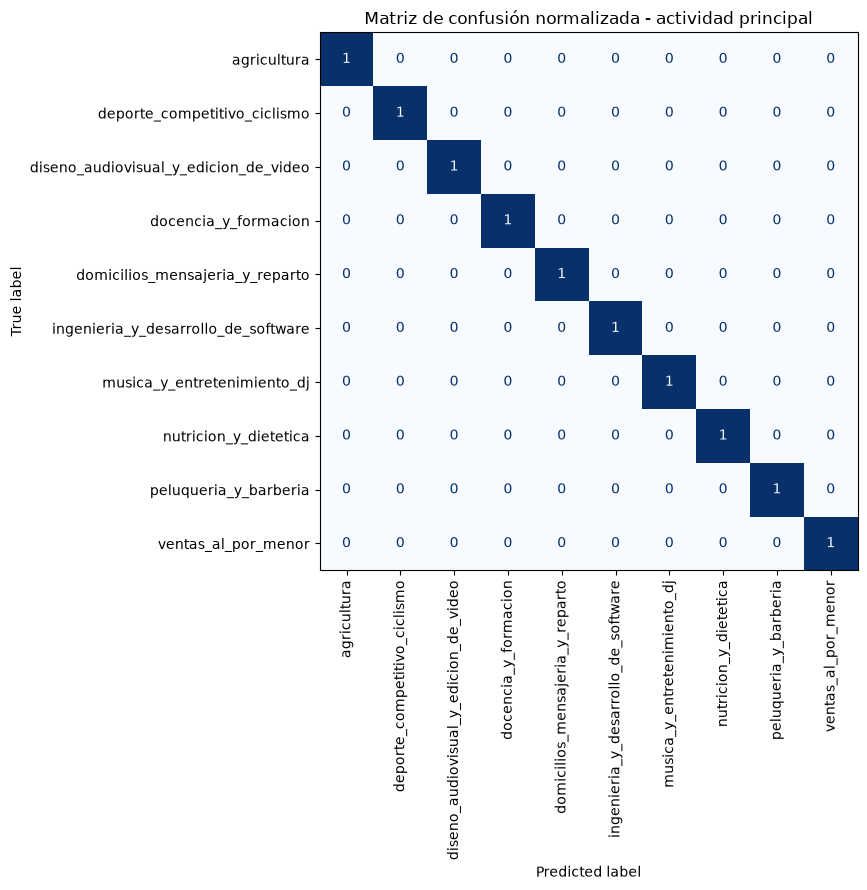

In [13]:
#Matriz de confusión
figura, eje = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=sorted(y_test.unique()),
    normalize='true',
    xticks_rotation=90,
    cmap='Blues',
    ax=eje,
    colorbar=False,
)
eje.set_title('Matriz de confusión normalizada - actividad principal')
plt.tight_layout()
plt.show()

## 8. Contexto declarado adicional

In [14]:
#Normalizar datos declarados
def normalizar_texto(texto):
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    texto = ''.join(caracter for caracter in texto if not unicodedata.combining(caracter))
    texto = texto.replace('_', ' ').replace('-', ' ')
    return ' '.join(texto.split())


variantes_hobbies = {
    'ciclismo': ['ciclismo', 'bicicleta'],
    'cocina_y_reposteria': ['cocina y reposteria', 'cocina', 'reposteria'],
    'fotografia_y_video': ['fotografia y video', 'fotografia', 'video'],
    'impresion_3d': ['impresion 3d', 'impresora 3d'],
    'jardineria_y_agricultura_urbana': ['jardineria y agricultura urbana', 'jardineria', 'agricultura urbana'],
    'manualidades_y_artesanias': ['manualidades y artesanias', 'manualidades', 'artesanias'],
    'musica': ['musica'],
    'pintura': ['pintura'],
    'turismo_y_viajes': ['turismo y viajes', 'turismo', 'viajes'],
    'videojuegos_y_streaming': ['videojuegos y streaming', 'videojuegos', 'streaming'],
}

assert set(variantes_hobbies) == set(catalogo_hobbies), 'Las variantes no cubren los diez hobbies'

In [15]:
#Validar contexto estructurado
revision_contexto = pd.DataFrame([
    {'control': 'modalidades de ingreso', 'errores': int((~datos_modelo['estado_ingreso_actual'].isin(modalidades_ingreso)).sum())},
    {'control': 'hábitos de ahorro', 'errores': int((~datos_modelo['habito_ahorro'].isin(habitos_ahorro)).sum())},
    {'control': 'ingresos no negativos', 'errores': int(pd.to_numeric(datos_modelo['ingreso_mensual_neto'], errors='coerce').lt(0).sum())},
    {'control': 'endeudamiento entre cero y cien', 'errores': int((~pd.to_numeric(datos_modelo.loc[datos_modelo['estado_calculo_endeudamiento'].eq('calculado'), 'nivel_endeudamiento_pct'], errors='coerce').between(0, 100)).sum())},
])

contexto_ok = bool(revision_contexto['errores'].eq(0).all())
display(pd.crosstab(datos_modelo['estado_ingreso_actual'], datos_modelo['particion']))
display(revision_contexto)
assert contexto_ok, 'El contexto estructurado contiene valores inválidos'

particion,test,train,validation
estado_ingreso_actual,,,
apoyo,3,14,3
estacional,3,14,3
fijo,7,35,8
mixto,6,28,6
sin_ingresos,3,14,3
variable,8,35,7


,control,errores
0,modalidades de ingreso,0
1,hábitos de ahorro,0
2,ingresos no negativos,0
3,endeudamiento entre cero y cien,0


In [16]:
#Preparar contexto declarado
def clasificar_hobbies_declarados(hobbies):
    if isinstance(hobbies, (list, tuple, set)):
        texto_hobbies = ' | '.join(str(hobby) for hobby in hobbies)
    else:
        texto_hobbies = str(hobbies or '')

    texto_normalizado = normalizar_texto(texto_hobbies)
    palabras_hobbies = set(texto_normalizado.replace('|', ' ').replace(',', ' ').replace(';', ' ').split())
    hobbies_encontrados = []

    for hobby, variantes in variantes_hobbies.items():
        coincidencias = []
        for variante in variantes:
            variante_normalizada = normalizar_texto(variante)
            coincide = (
                variante_normalizada in texto_normalizado
                if ' ' in variante_normalizada
                else variante_normalizada in palabras_hobbies
            )
            coincidencias.append(coincide)
        if any(coincidencias):
            hobbies_encontrados.append(hobby)

    fuera_del_mvp = []
    if texto_normalizado and not hobbies_encontrados:
        fuera_del_mvp.append(texto_hobbies.strip())

    return hobbies_encontrados, fuera_del_mvp


def resolver_estado_ingreso(ingreso_mensual, modalidad_declarada):
    if ingreso_mensual == 0:
        return 'sin_ingresos'
    if modalidad_declarada not in modalidades_ingreso or modalidad_declarada == 'sin_ingresos':
        raise ValueError('modalidad_ingreso_principal no es válida para un ingreso mayor que cero')
    return modalidad_declarada


def resolver_endeudamiento(ingreso_mensual, tipos_deuda, nivel_endeudamiento):
    tiene_deuda = bool(str(tipos_deuda or '').strip()) and normalizar_texto(tipos_deuda) != 'sin deuda'
    if ingreso_mensual == 0:
        return 'no_calculable_sin_ingresos' if tiene_deuda else 'sin_ingresos_sin_pago_observado'
    if nivel_endeudamiento is None or not 0 <= float(nivel_endeudamiento) <= 100:
        raise ValueError('nivel_endeudamiento_pct debe estar entre cero y cien')
    return 'calculado'

## 9. Función de conocimiento del usuario

In [17]:
#Definir inferencia
def convertir_lista(valor):
    if isinstance(valor, (list, tuple, set)):
        return [str(elemento).strip() for elemento in valor if str(elemento).strip()]
    if not str(valor or '').strip():
        return []
    return [str(valor).strip()]


def clasificar_usuario(test_usuario, umbral_alcance=UMBRAL_ALCANCE):
    if not isinstance(test_usuario, dict):
        raise TypeError('test_usuario debe ser un diccionario')

    actividad_declarada = str(
        test_usuario.get('actividad_principal_declarada')
        or test_usuario.get('ingreso_principal')
        or ''
    ).strip()
    if not actividad_declarada:
        raise ValueError('actividad_principal_declarada debe contener texto')

    ingreso_mensual = float(test_usuario.get('ingreso_mensual_neto', 0))
    if ingreso_mensual < 0:
        raise ValueError('ingreso_mensual_neto no puede ser negativo')

    modalidad_declarada = str(test_usuario.get('modalidad_ingreso_principal', '')).strip().lower()
    estado_ingreso = resolver_estado_ingreso(ingreso_mensual, modalidad_declarada)
    nivel_endeudamiento = test_usuario.get('nivel_endeudamiento_pct')
    tipos_deuda = convertir_lista(test_usuario.get('tipos_deuda', []))
    estado_endeudamiento = resolver_endeudamiento(
        ingreso_mensual,
        ' | '.join(tipos_deuda),
        nivel_endeudamiento,
    )

    habito_ahorro = str(test_usuario.get('habito_ahorro', '')).strip().lower()
    if habito_ahorro not in habitos_ahorro:
        raise ValueError('habito_ahorro debe ser nunca, baja, media o alta')

    hobbies, hobbies_fuera_mvp = clasificar_hobbies_declarados(test_usuario.get('hobbies', []))
    resultados_actividad = puntuar_actividad(actividad_declarada)
    mejor_resultado = resultados_actividad[0]
    actividad_principal = mejor_resultado['actividad']
    confianza_principal = mejor_resultado['confianza']
    top_3_actividades = [
        {
            'actividad': resultado['actividad'],
            'porcentaje': round(resultado['confianza'] * 100, 2),
        }
        for resultado in resultados_actividad[:3]
    ]

    tiene_ingreso_adicional = bool(test_usuario.get('tiene_ingreso_adicional', False))
    ingreso_adicional = str(test_usuario.get('ingreso_adicional', '') or '').strip()
    actividad_secundaria = 'no_declarada'
    if tiene_ingreso_adicional and ingreso_adicional:
        resultado_secundario = puntuar_actividad(ingreso_adicional)[0]
        actividad_secundaria = (
            resultado_secundario['actividad']
            if resultado_secundario['confianza'] >= umbral_alcance
            else 'fuera_del_mvp'
        )

    contexto_declarado = {
        'actividad_declarada': actividad_declarada,
        'ingreso_mensual_neto': ingreso_mensual,
        'estado_ingreso_actual': estado_ingreso,
        'modalidad_ingreso_principal': estado_ingreso,
        'fuente_modalidad': 'declarada_por_usuario',
        'actividad_secundaria': actividad_secundaria,
        'ingreso_adicional': ingreso_adicional if tiene_ingreso_adicional else 'no_declarado',
        'hobbies_intereses': hobbies if hobbies else ['no_declarado'],
        'hobbies_fuera_mvp': hobbies_fuera_mvp,
        'meta': str(test_usuario.get('objetivo_proximo', '') or 'no_declarada').strip(),
        'responsabilidad': str(test_usuario.get('responsabilidad_financiera', '') or 'no_declarada').strip(),
        'tipos_deuda': tipos_deuda if tipos_deuda else ['sin_deuda'],
        'nivel_endeudamiento_pct': float(nivel_endeudamiento) if nivel_endeudamiento is not None else None,
        'estado_calculo_endeudamiento': estado_endeudamiento,
        'habito_ahorro': habito_ahorro,
    }

    if confianza_principal < umbral_alcance:
        return {
            **contexto_declarado,
            'estado_alcance_mvp': 'no_disponible',
            'actividad_principal': 'no_disponible',
            'ocupacion_cuoc': 'no_disponible',
            'codigo_cuoc': 'no_disponible',
            'confianza_actividad_pct': round(confianza_principal * 100, 2),
            'probabilidad_modelo_pct': round(mejor_resultado['probabilidad_modelo'] * 100, 2),
            'similitud_catalogo_pct': round(mejor_resultado['similitud_catalogo'] * 100, 2),
            'top_3_actividades': top_3_actividades,
            'motivo': 'La actividad declarada no alcanzó el 50% dentro del catálogo cerrado del MVP',
            'principio_etico': 'Los datos declarados se conservan sin inventar profesión, ingresos, hobbies ni responsabilidades.',
            'version_modelo': VERSION_MODELO,
        }

    return {
        **contexto_declarado,
        'estado_alcance_mvp': 'dentro_del_mvp',
        'actividad_principal': actividad_principal,
        'ocupacion_cuoc': mapa_ocupacion.get(actividad_principal, 'no_disponible'),
        'codigo_cuoc': mapa_codigo_cuoc.get(actividad_principal, 'no_disponible'),
        'confianza_actividad_pct': round(confianza_principal * 100, 2),
        'probabilidad_modelo_pct': round(mejor_resultado['probabilidad_modelo'] * 100, 2),
        'similitud_catalogo_pct': round(mejor_resultado['similitud_catalogo'] * 100, 2),
        'top_3_actividades': top_3_actividades,
        'motivo': 'Actividad reconocida dentro de las diez ocupaciones del MVP',
        'principio_etico': 'Los datos declarados se conservan sin inventar profesión, ingresos, hobbies ni responsabilidades.',
        'version_modelo': VERSION_MODELO,
    }

## 10. Serialización

In [18]:
#Guardar modelo
ruta_modelos = Path('../Modelos')
ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_artefacto = ruta_modelos / '01_conocimiento_usuario.joblib'

artefacto_usuario = {
    'version_modelo': VERSION_MODELO,
    'modelo_actividad': modelo_actividad,
    'nombre_modelo_actividad': nombre_modelo_actividad,
    'vectorizador_catalogo': vectorizador_catalogo,
    'matriz_catalogo': matriz_catalogo,
    'familias_catalogo': familias_catalogo,
    'muestras_catalogo': muestras_catalogo,
    'variantes_actividad': variantes_actividad,
    'variantes_hobbies': variantes_hobbies,
    'mapa_ocupacion': mapa_ocupacion,
    'mapa_codigo_cuoc': mapa_codigo_cuoc,
    'catalogo_hobbies': catalogo_hobbies,
    'modalidades_ingreso': modalidades_ingreso,
    'habitos_ahorro': habitos_ahorro,
    'umbral_alcance': UMBRAL_ALCANCE,
    'peso_modelo': PESO_MODELO,
    'peso_catalogo': PESO_CATALOGO,
    'campos_entrada': [
        'actividad_principal_declarada', 'ingreso_mensual_neto',
        'modalidad_ingreso_principal', 'tiene_ingreso_adicional',
        'ingreso_adicional', 'modalidad_ingreso_adicional',
        'objetivo_proximo', 'hobbies', 'responsabilidad_financiera',
        'tipos_deuda', 'nivel_endeudamiento_pct', 'habito_ahorro',
    ],
    'version_esquema': sorted(datos_modelo['version_esquema'].dropna().unique().tolist()),
}

joblib.dump(artefacto_usuario, ruta_artefacto)
print(f'Modelo guardado en: {ruta_artefacto}')

Modelo guardado en: ../Modelos/01_conocimiento_usuario.joblib


## 11. Pruebas manuales

In [19]:
#Casos dentro del MVP
test_clasificables = [
    {
        'actividad_principal_declarada': 'Desarrollador de software',
        'ingreso_mensual_neto': 4500000,
        'modalidad_ingreso_principal': 'fijo',
        'tiene_ingreso_adicional': False,
        'ingreso_adicional': '',
        'modalidad_ingreso_adicional': '',
        'objetivo_proximo': 'crear un fondo de emergencia',
        'hobbies': ['ciclismo', 'videojuegos'],
        'responsabilidad_financiera': 'aporte al hogar',
        'tipos_deuda': ['credito'],
        'nivel_endeudamiento_pct': 18,
        'habito_ahorro': 'media',
        'actividad_esperada': 'ingenieria_y_desarrollo_de_software',
    },
    {
        'actividad_principal_declarada': 'Venta de alimentos al por menor',
        'ingreso_mensual_neto': 2100000,
        'modalidad_ingreso_principal': 'variable',
        'tiene_ingreso_adicional': False,
        'ingreso_adicional': '',
        'modalidad_ingreso_adicional': '',
        'objetivo_proximo': 'ampliar la actividad economica',
        'hobbies': ['cocina y reposteria'],
        'responsabilidad_financiera': 'gastos de un hijo',
        'tipos_deuda': [],
        'nivel_endeudamiento_pct': 0,
        'habito_ahorro': 'baja',
        'actividad_esperada': 'ventas_al_por_menor',
    },
    {
        'actividad_principal_declarada': 'DJ',
        'ingreso_mensual_neto': 3800000,
        'modalidad_ingreso_principal': 'mixto',
        'tiene_ingreso_adicional': True,
        'ingreso_adicional': 'Editor de video',
        'modalidad_ingreso_adicional': 'variable',
        'objetivo_proximo': 'comprar equipo de trabajo',
        'hobbies': ['musica', 'fotografia'],
        'responsabilidad_financiera': '',
        'tipos_deuda': ['credito'],
        'nivel_endeudamiento_pct': 25,
        'habito_ahorro': 'alta',
        'actividad_esperada': 'musica_y_entretenimiento_dj',
    },
]

resultados_clasificables = []

for caso in test_clasificables:
    actividad_esperada = caso['actividad_esperada']
    test_usuario = {clave: valor for clave, valor in caso.items() if clave != 'actividad_esperada'}
    resultado = clasificar_usuario(test_usuario)
    resultado['actividad_esperada'] = actividad_esperada
    resultado['cumple_esperado'] = (
        resultado['estado_alcance_mvp'] == 'dentro_del_mvp'
        and resultado['actividad_principal'] == actividad_esperada
    )
    resultados_clasificables.append(resultado)

columnas_resultado = [
    'actividad_declarada',
    'estado_alcance_mvp',
    'actividad_principal',
    'actividad_esperada',
    'confianza_actividad_pct',
    'estado_ingreso_actual',
    'actividad_secundaria',
    'modalidad_ingreso_principal',
    'hobbies_intereses',
    'meta',
    'responsabilidad',
    'top_3_actividades',
    'cumple_esperado',
]

resultados_clasificables = pd.DataFrame(resultados_clasificables)
display(resultados_clasificables[columnas_resultado])
assert resultados_clasificables['cumple_esperado'].all(), 'Uno de los casos clasificables no cumplió la salida esperada'

,actividad_declarada,estado_alcance_mvp,actividad_principal,actividad_esperada,confianza_actividad_pct,estado_ingreso_actual,actividad_secundaria,modalidad_ingreso_principal,hobbies_intereses,meta,responsabilidad,top_3_actividades,cumple_esperado
0,Desarrollador de software,dentro_del_mvp,ingenieria_y_desarrollo_de_software,ingenieria_y_desarrollo_de_software,95.06,fijo,no_declarada,fijo,"[ciclismo, videojuegos_y_streaming]",crear un fondo de emergencia,aporte al hogar,[{'actividad': 'ingenieria_y_desarrollo_de_sof...,True
1,Venta de alimentos al por menor,dentro_del_mvp,ventas_al_por_menor,ventas_al_por_menor,90.07,variable,no_declarada,variable,[cocina_y_reposteria],ampliar la actividad economica,gastos de un hijo,"[{'actividad': 'ventas_al_por_menor', 'porcent...",True
2,DJ,dentro_del_mvp,musica_y_entretenimiento_dj,musica_y_entretenimiento_dj,88.62,mixto,diseno_audiovisual_y_edicion_de_video,mixto,"[fotografia_y_video, musica]",comprar equipo de trabajo,no_declarada,"[{'actividad': 'musica_y_entretenimiento_dj', ...",True


In [20]:
#Caso fuera del MVP
test_no_clasificable = {
    'actividad_principal_declarada': 'Mecanico automotriz',
    'ingreso_mensual_neto': 2400000,
    'modalidad_ingreso_principal': 'variable',
    'tiene_ingreso_adicional': False,
    'ingreso_adicional': '',
    'modalidad_ingreso_adicional': '',
    'objetivo_proximo': 'comprar herramientas',
    'hobbies': ['natacion'],
    'responsabilidad_financiera': 'aporte al hogar',
    'tipos_deuda': [],
    'nivel_endeudamiento_pct': 0,
    'habito_ahorro': 'baja',
    'salida_esperada': 'no_disponible',
}

salida_esperada = test_no_clasificable['salida_esperada']
test_usuario = {clave: valor for clave, valor in test_no_clasificable.items() if clave != 'salida_esperada'}
resultado_no_clasificable = clasificar_usuario(test_usuario)
resultado_no_clasificable['salida_esperada'] = salida_esperada
resultado_no_clasificable['cumple_esperado'] = (
    resultado_no_clasificable['estado_alcance_mvp'] == salida_esperada
    and resultado_no_clasificable['actividad_principal'] == salida_esperada
)

display(pd.DataFrame([resultado_no_clasificable]))
assert resultado_no_clasificable['cumple_esperado'], 'El caso fuera del MVP fue forzado a una actividad disponible'

,actividad_declarada,ingreso_mensual_neto,estado_ingreso_actual,modalidad_ingreso_principal,fuente_modalidad,actividad_secundaria,ingreso_adicional,hobbies_intereses,hobbies_fuera_mvp,meta,...,codigo_cuoc,confianza_actividad_pct,probabilidad_modelo_pct,similitud_catalogo_pct,top_3_actividades,motivo,principio_etico,version_modelo,salida_esperada,cumple_esperado
0,Mecanico automotriz,2400000.0,variable,variable,declarada_por_usuario,no_declarada,no_declarado,[no_declarado],[natacion],comprar herramientas,...,no_disponible,13.25,10.58,16.51,"[{'actividad': 'nutricion_y_dietetica', 'porce...",La actividad declarada no alcanzó el 50% dentr...,Los datos declarados se conservan sin inventar...,fincoach_usuario_mvp_v2,no_disponible,True
